Saving data.csv to data (1).csv
Train size: (455, 30), Test size: (114, 30)
Using device: cpu
Epoch   1 | Train Loss: 0.4339 | Val Loss: 0.2976
Epoch  20 | Train Loss: 0.0742 | Val Loss: 0.0870
Epoch  40 | Train Loss: 0.0455 | Val Loss: 0.0759
Early stopping at epoch 57

Best validation loss: 0.0711 at epoch 27

TEST SET PERFORMANCE
Accuracy:  0.9825  (98.25%)
Precision: 1.0000
Recall:    0.9524
F1-score:  0.9756

Confusion Matrix:
[[72  0]
 [ 2 40]]


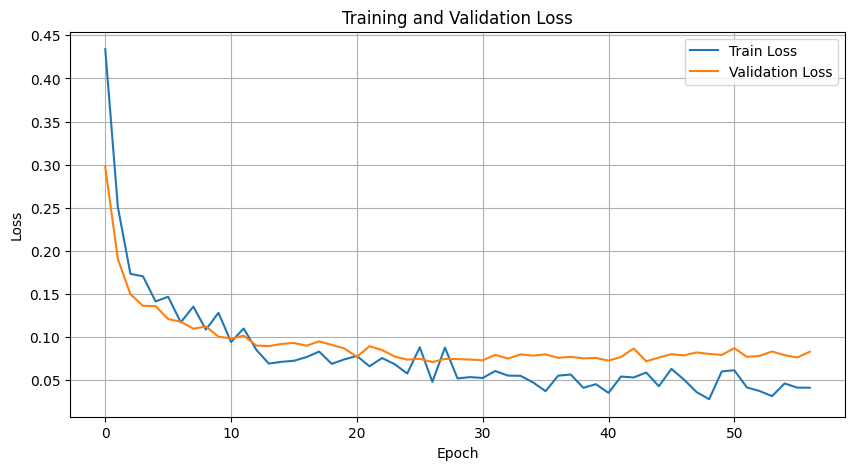

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('data.csv')

df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class BreastCancerNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.model(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = BreastCancerNN(input_dim=X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

epochs = 300
patience = 30
best_val_loss = float('inf')
best_epoch = 0
early_stop_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(test_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        early_stop_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\nBest validation loss: {best_val_loss:.4f} at epoch {best_epoch}")

model.load_state_dict(torch.load('best_model.pt'))

model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_tensor.to(device)).cpu().numpy()
    y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
    y_true = y_test_tensor.numpy().flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\n" + "="*50)
print("TEST SET PERFORMANCE")
print("="*50)
print(f"Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()